# Risk-Controlling Prediction Sets (RCPS): MNIST denoising

**Video walkthrough notebook.** We use real handwritten digit images as targets and create noisy versions as inputs. A small convolutional network predicts a denoised image and two pixelwise quantiles. RCPS then calibrates one shared interval scale on held-out images.

This is a compact, real image-to-image task. The corruption is simulated for teaching; this is not FastMRI or one of the paper's biological imaging experiments.

**Roadmap**
1. Load MNIST and make disjoint training, calibration, and test splits.
2. Corrupt clean digits to create paired input/target images.
3. Train a CNN for the median image and lower/upper conditional quantiles.
4. Calibrate the interval scale using image-level risk and the paper's Hoeffding upper bound.
5. Evaluate and visualize intervals, then repeat calibration on fresh samples.

Paper: Angelopoulos et al., [Image-to-Image Regression with Distribution-Free Uncertainty Quantification and Applications in Imaging](https://arxiv.org/abs/2202.05265).

In [1]:
# Run this notebook in the repository's im2im-uq environment (PyTorch + torchvision).
import math, random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

SEED = 2026
ALPHA = 0.10
DELTA = 0.10
BATCH_SIZE = 128
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Target risk alpha={ALPHA}; failure probability delta={DELTA}")

Device: cpu
Target risk alpha=0.1; failure probability delta=0.1


## 1. Data and the image-to-image task

Each clean MNIST digit is the target image **Y**. We corrupt it to create the model input **X**. To make the corruption visibly non-uniform and asymmetric, we add centered lognormal noise whose scale increases with the clean pixel intensity, then clip to the valid grayscale range [0,1].

The splits are image-disjoint: training digits fit the model, calibration digits choose lambda, and test digits are held aside for evaluation.

In [2]:
# torchvision downloads the standard MNIST files on first use.
train_set = MNIST(root="data", train=True, download=True, transform=ToTensor())
test_set = MNIST(root="data", train=False, download=True, transform=ToTensor())

# Deterministic split: 15,000 model-training, 2,500 calibration, 2,500 validation.
perm = torch.randperm(len(train_set), generator=torch.Generator().manual_seed(SEED)).tolist()
train_ids, cal_ids, val_ids = perm[:15000], perm[15000:17500], perm[17500:20000]
train_ds = Subset(train_set, train_ids)
cal_ds = Subset(train_set, cal_ids)
val_ds = Subset(train_set, val_ids)

# Reserve disjoint halves of the official test set for the main example and repeated check.
test_ids = list(range(len(test_set)))
main_test_ds = Subset(test_set, test_ids[:2500])
repeat_cal_pool = Subset(test_set, test_ids[2500:6250])
repeat_test_pool = Subset(test_set, test_ids[6250:])

print(f"train={len(train_ds)}, calibration={len(cal_ds)}, validation={len(val_ds)}")
print(f"main test={len(main_test_ds)}, repeated-check pools={len(repeat_cal_pool)} + {len(repeat_test_pool)}")

train=15000, calibration=2500, validation=2500
main test=2500, repeated-check pools=3750 + 3750


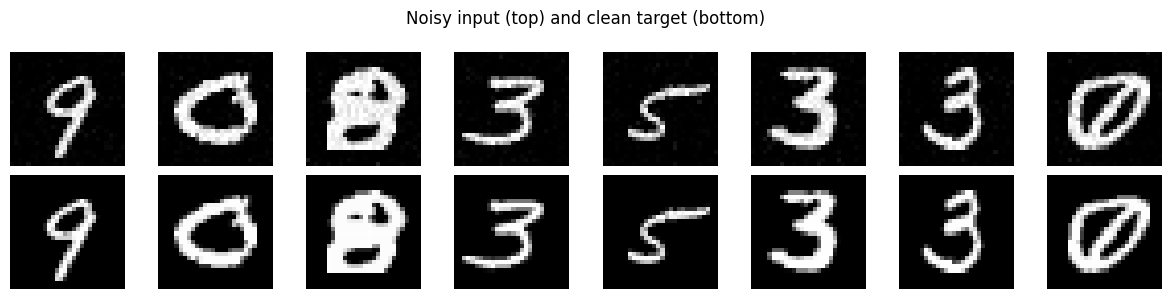

In [3]:
def corrupt(clean):
    """Centered, right-skewed lognormal sensor noise; stronger on bright pixels."""
    sigma = 0.55
    centered_lognormal = torch.exp(sigma * torch.randn_like(clean) - 0.5 * sigma**2) - 1.0
    scale = 0.025 + 0.16 * clean
    noisy = (clean + scale * centered_lognormal).clamp(0.0, 1.0)
    return noisy

clean_batch = torch.stack([train_ds[i][0] for i in range(8)])
noisy_batch = corrupt(clean_batch)
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for j in range(8):
    axes[0,j].imshow(noisy_batch[j,0], cmap="gray", vmin=0, vmax=1)
    axes[1,j].imshow(clean_batch[j,0], cmap="gray", vmin=0, vmax=1)
    axes[0,j].axis("off"); axes[1,j].axis("off")
axes[0,0].set_ylabel("input X"); axes[1,0].set_ylabel("target Y")
fig.suptitle("Noisy input (top) and clean target (bottom)")
plt.tight_layout(); plt.show()

## 2. Train the point predictor and interval shape

The CNN outputs three channels per pixel: a median estimate, a lower quantile, and an upper quantile. We train the center with squared error and the two quantile channels with pinball loss at alpha/2 and 1-alpha/2 (5th and 95th percentiles).

The quantile estimates provide a useful, possibly imperfect asymmetric interval shape. They do **not** guarantee coverage on their own. The calibration step will adjust their widths.

In [4]:
class SmallImageRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 3, 1),
        )
    def forward(self, x):
        return self.net(x)

def pinball(pred, target, q):
    err = target - pred
    return torch.maximum(q * err, (q - 1) * err).mean()

model = SmallImageRegressor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
epochs = 4
for epoch in range(epochs):
    model.train()
    running = 0.0
    for clean, _ in train_loader:
        clean = clean.to(device)
        noisy = corrupt(clean)
        pred = model(noisy)
        center, qlo, qhi = pred[:,0:1], pred[:,1:2], pred[:,2:3]
        loss = pinball(center, clean, 0.5) + pinball(qlo, clean, ALPHA/2) + pinball(qhi, clean, 1-ALPHA/2)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item() * len(clean)
    print(f"epoch {epoch+1}/{epochs} | mean training loss {running/len(train_ds):.4f}")

epoch 1/4 | mean training loss 0.0438
epoch 2/4 | mean training loss 0.0085
epoch 3/4 | mean training loss 0.0072
epoch 4/4 | mean training loss 0.0066


## 3. Define pixel intervals and image-level risk

For an image, the loss is the **fraction of pixels outside** their intervals. That gives one bounded [0,1] risk value per image, matching Definition 1 in the paper.

The model's quantile outputs are converted to lower and upper radii around the predicted median. A candidate scale lambda makes the pixel interval:

\[
[\hat f(X) - \lambda\tilde l(X),\quad \hat f(X)+\lambda\tilde u(X)].
\]

As lambda grows, intervals only widen, so the sets are nested.

In [5]:
@torch.no_grad()
def predict_parts(noisy):
    model.eval()
    out = model(noisy.to(device))
    center, qlo, qhi = out[:,0:1], out[:,1:2], out[:,2:3]
    # Positive asymmetric widths; protect against quantile crossing.
    rlo = (center - qlo).clamp_min(1e-4)
    rhi = (qhi - center).clamp_min(1e-4)
    return center, rlo, rhi

@torch.no_grad()
def required_pixel_scales(dataset, batch_size=BATCH_SIZE):
    """Minimum lambda needed to include each target pixel."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    chunks = []
    for clean, _ in loader:
        noisy = corrupt(clean).to(device)
        target = clean.to(device)
        center, rlo, rhi = predict_parts(noisy)
        needed = torch.where(target < center, (center-target)/rlo, (target-center)/rhi)
        chunks.append(needed.clamp_min(0).flatten(1).cpu().numpy())
    return np.concatenate(chunks, axis=0)

def risks_at_scale(scores, lam):
    return np.mean(scores > lam, axis=1)

def hoeffding_upper(risks, delta=DELTA):
    return float(risks.mean() + math.sqrt(math.log(1/delta)/(2*len(risks))))


## 4. RCPS calibration: calculate lambda

For each candidate lambda, measure calibration risk on each image, average those bounded losses, then add the Hoeffding adjustment:

\[
R^+(\lambda)=\frac{1}{n}\sum_{i=1}^n L_i(\lambda)+\sqrt{\frac{\log(1/\delta)}{2n}}.
\]

Algorithm 2 reduces lambda from a wide starting interval until the bound exceeds alpha, then backs up one step. The loop below shows that search explicitly and returns the smallest feasible scale on its grid.

In [6]:
def calibrate_lambda(dataset, alpha=ALPHA, delta=DELTA, lam_max=6.0, step=0.02):
    # Predict once; each pixel's required scale evaluates all nested intervals.
    scores = required_pixel_scales(dataset)
    ordered = np.sort(scores.reshape(-1))
    n_images = scores.shape[0]
    grid = np.arange(lam_max, -step/2, -step)
    additive = math.sqrt(math.log(1/delta)/(2*n_images))
    trace, chosen = [], None
    for lam in grid:
        mean_risk = 1.0 - np.searchsorted(ordered, lam, side="right") / len(ordered)
        bound = mean_risk + additive
        trace.append((lam, mean_risk, bound))
        if bound <= alpha:
            chosen = float(lam)
        elif chosen is not None:
            break
    if chosen is None:
        raise RuntimeError("No feasible lambda. Increase calibration data or lam_max.")
    return chosen, np.asarray(trace), scores

lambda_hat, calibration_trace, cal_scores = calibrate_lambda(cal_ds)
cal_risks = risks_at_scale(cal_scores, lambda_hat)
print(f"lambda_hat = {lambda_hat:.2f}")
print(f"mean calibration risk = {cal_risks.mean():.4f}")
print(f"Hoeffding adjustment = {math.sqrt(math.log(1/DELTA)/(2*len(cal_risks))):.4f}")
print(f"R+(lambda_hat) = {hoeffding_upper(cal_risks):.4f} <= alpha={ALPHA}")

lambda_hat = 0.78
mean calibration risk = 0.0783
Hoeffding adjustment = 0.0215
R+(lambda_hat) = 0.0997 <= alpha=0.1


## 5. Evaluate and visualize on held-out digits

We now freeze the model and calibrated lambda. The test set reports empirical image-level risk and average interval width. The figure shows input, target, point prediction, and interval width for a few unseen digits.

held-out mean image-level risk = 0.0764 (target alpha=0.10)
mean interval width for shown examples = 0.0165


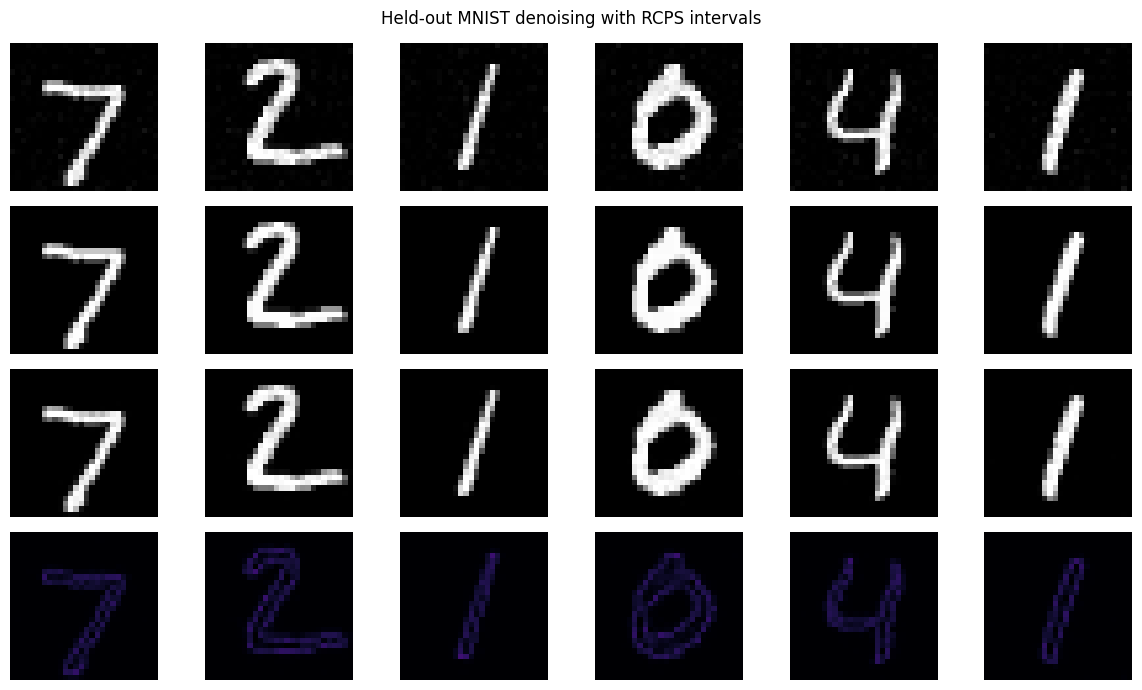

In [7]:
@torch.no_grad()
def evaluate_and_collect(dataset, lam, max_images=None):
    scores = required_pixel_scales(dataset)
    risks = risks_at_scale(scores, lam)
    examples = []
    if max_images:
        subset = Subset(dataset, list(range(min(max_images, len(dataset)))))
        clean, _ = next(iter(DataLoader(subset, batch_size=max_images, shuffle=False, num_workers=0)))
        noisy = corrupt(clean).to(device)
        center, rlo, rhi = predict_parts(noisy)
        lo, hi = (center-lam*rlo).clamp(0,1), (center+lam*rhi).clamp(0,1)
        for j in range(len(clean)):
            examples.append((noisy[j,0].cpu(), clean[j,0], center[j,0].clamp(0,1).cpu(), (hi[j,0]-lo[j,0]).cpu()))
    return risks, examples

test_risks, examples = evaluate_and_collect(main_test_ds, lambda_hat, max_images=6)
width_means = [ex[3].mean().item() for ex in examples]
print(f"held-out mean image-level risk = {test_risks.mean():.4f} (target alpha={ALPHA:.2f})")
print(f"mean interval width for shown examples = {np.mean(width_means):.4f}")

fig, axes = plt.subplots(4, 6, figsize=(12, 7))
titles = ["Noisy input X", "Clean target Y", "Predicted median", "Interval width"]
for j, ex in enumerate(examples):
    for row, img in enumerate(ex):
        axes[row,j].imshow(img, cmap="magma" if row==3 else "gray", vmin=0, vmax=1)
        axes[row,j].axis("off")
        if j==0: axes[row,j].set_ylabel(titles[row])
fig.suptitle("Held-out MNIST denoising with RCPS intervals")
plt.tight_layout(); plt.show()

## 6. Repeat calibration to inspect the (alpha, delta) behavior

Keep the trained model fixed, as in the calibration guarantee. For each trial, draw a fresh calibration sample from one held-out pool, recalibrate lambda, then estimate its test risk on an independent held-out pool. Repeating this 300 times shows how often the estimated test risk exceeds alpha.

This is an empirical check, not a proof. It uses finite test batches and the MNIST test set as a proxy for the population, so the observed fraction can fluctuate around delta.

In [ ]:
def draw_indices(dataset, n, rng):
    ids = rng.integers(0, len(dataset), size=n)
    return Subset(dataset, ids.tolist())

N_TRIALS = 300
N_CAL_TRIAL, N_TEST_TRIAL = 1000, 500
repeat_rng = np.random.default_rng(SEED+1)
trial_risks, trial_lambdas = np.empty(N_TRIALS), np.empty(N_TRIALS)

for t in range(N_TRIALS):
    cal_sample = draw_indices(repeat_cal_pool, N_CAL_TRIAL, repeat_rng)
    test_sample = draw_indices(repeat_test_pool, N_TEST_TRIAL, repeat_rng)
    lam, _, _ = calibrate_lambda(cal_sample)
    test_scores = required_pixel_scales(test_sample)
    trial_lambdas[t] = lam
    trial_risks[t] = risks_at_scale(test_scores, lam).mean()
    if (t+1) % 25 == 0: print(f"completed {t+1}/{N_TRIALS}")

failure_rate = np.mean(trial_risks > ALPHA)
print(f"test risk > alpha: {(trial_risks>ALPHA).sum()}/{N_TRIALS} = {failure_rate:.3f}")
print(f"requested delta = {DELTA:.2f}; mean trial risk = {trial_risks.mean():.4f}")
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(trial_risks, bins=np.linspace(0, max(.2, trial_risks.max()+.01), 26), edgecolor="white")
ax.axvline(ALPHA, color="C3", lw=2, label=f"alpha={ALPHA:.2f}")
ax.set(xlabel="test mean image-level risk", ylabel="trials", title="Risk over 300 fresh calibration samples")
ax.legend(); ax.grid(axis="y", alpha=.2); plt.show()


completed 25/300
completed 50/300


## Wrap-up: where CP and RCPS appear

- **Model / heuristic:** the CNN proposes a center and pixelwise interval shape using training images.
- **Calibration:** RCPS measures one fraction-missed loss per calibration image and uses the Hoeffding upper bound to set lambda.
- **Prediction set:** the scaled lower/upper widths form an interval at every pixel of a new input image.
- This is **not split conformal prediction's quantile-of-scores recipe**. It is the paper's risk-controlling calibration procedure (RCPS), with a Hoeffding bound on bounded image-level loss.
- The guarantee is marginal over calibration samples: with probability at least 1-delta, expected risk on a new image is at most alpha. It does not promise coverage of every pixel or every individual image.

For an explanation video, emphasize: **the network proposes; calibration checks how often it misses and expands intervals until the risk bound passes.**